In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from fishsense_imwut.camera import reconstruct_points
from matplotlib.patches import Ellipse, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

## Setup of Simulation
The following reasonable defaults that match the systems we tested against.

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850
LASER_DIAMETER_M = 5.6 * 1e-3  # Convert mm to meters

IMAGE_WIDTH, IMAGE_HEIGHT, FOCAL_LENGTH_PX, LASER_DIAMETER_M

(4014, 3016, 2850, 0.0056)

In [3]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1]
])
inverted_camera_intrinsics = np.linalg.inv(camera_intrinsics)

camera_intrinsics, inverted_camera_intrinsics

(array([[2.850e+03, 0.000e+00, 2.007e+03],
        [0.000e+00, 2.850e+03, 1.508e+03],
        [0.000e+00, 0.000e+00, 1.000e+00]]),
 array([[ 3.50877193e-04,  0.00000000e+00, -7.04210526e-01],
        [ 0.00000000e+00,  3.50877193e-04, -5.29122807e-01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]))

In [4]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([1e-10, 1e-10, 1])

laser_params = np.concatenate([laser_direction, laser_position[:2]])

laser_position, laser_direction, laser_params

(array([-0.04, -0.11,  0.  ]),
 array([1.e-10, 1.e-10, 1.e+00]),
 array([ 1.0e-10,  1.0e-10,  1.0e+00, -4.0e-02, -1.1e-01]))

## Next we setup data we can use for testing

In [5]:
STEP_COUNT = 1000
t = np.linspace(0, 30, STEP_COUNT)

STEP_COUNT, t

(1000,
 array([ 0.        ,  0.03003003,  0.06006006,  0.09009009,  0.12012012,
         0.15015015,  0.18018018,  0.21021021,  0.24024024,  0.27027027,
         0.3003003 ,  0.33033033,  0.36036036,  0.39039039,  0.42042042,
         0.45045045,  0.48048048,  0.51051051,  0.54054054,  0.57057057,
         0.6006006 ,  0.63063063,  0.66066066,  0.69069069,  0.72072072,
         0.75075075,  0.78078078,  0.81081081,  0.84084084,  0.87087087,
         0.9009009 ,  0.93093093,  0.96096096,  0.99099099,  1.02102102,
         1.05105105,  1.08108108,  1.11111111,  1.14114114,  1.17117117,
         1.2012012 ,  1.23123123,  1.26126126,  1.29129129,  1.32132132,
         1.35135135,  1.38138138,  1.41141141,  1.44144144,  1.47147147,
         1.5015015 ,  1.53153153,  1.56156156,  1.59159159,  1.62162162,
         1.65165165,  1.68168168,  1.71171171,  1.74174174,  1.77177177,
         1.8018018 ,  1.83183183,  1.86186186,  1.89189189,  1.92192192,
         1.95195195,  1.98198198,  2.0120120

In [6]:
p = laser_position[:, np.newaxis] + t[np.newaxis, :] * laser_direction[:, np.newaxis]

p

array([[-0.04      , -0.04      , -0.04      , ..., -0.04      ,
        -0.04      , -0.04      ],
       [-0.11      , -0.11      , -0.11      , ..., -0.11      ,
        -0.11      , -0.11      ],
       [ 0.        ,  0.03003003,  0.06006006, ..., 29.93993994,
        29.96996997, 30.        ]], shape=(3, 1000))

In [7]:
s = p / p[2, :]
s = camera_intrinsics @ s

s

/tmp/ipykernel_1493181/932217983.py:1: RuntimeWarning: divide by zero encountered in divide
  s = p / p[2, :]
/tmp/ipykernel_1493181/932217983.py:1: RuntimeWarning: invalid value encountered in divide
  s = p / p[2, :]
/tmp/ipykernel_1493181/932217983.py:2: RuntimeWarning: invalid value encountered in matmul
  s = camera_intrinsics @ s


array([[            nan, -1.78920000e+03,  1.08900000e+02, ...,
         2.00319238e+03,  2.00319619e+03,  2.00320000e+03],
       [            nan, -8.93155000e+03, -3.71177500e+03, ...,
         1.49752904e+03,  1.49753953e+03,  1.49755000e+03],
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00]],
      shape=(3, 1000))

In [8]:
s_pixel = np.round(s)

s_pixel

array([[       nan, -1.789e+03,  1.090e+02, ...,  2.003e+03,  2.003e+03,
         2.003e+03],
       [       nan, -8.932e+03, -3.712e+03, ...,  1.498e+03,  1.498e+03,
         1.498e+03],
       [       nan,  1.000e+00,  1.000e+00, ...,  1.000e+00,  1.000e+00,
         1.000e+00]], shape=(3, 1000))

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/chris/Repos/school/e4e/fishsense/imwut_2026_fishsense_lite/fishsense_imwut/camera.py:39: RuntimeWarning: divide by zero encountered in divide
  point_constants_noisy = (
/home/chris/Repos/school/e4e/fishsense/imwut_2026_fishsense_lite/fishsense_imwut/camera.py:43: RuntimeWarning: invalid value encountered in multiply
  world_points = np.tile(point_constants_noisy, (3, 1)) * final_laser_axis


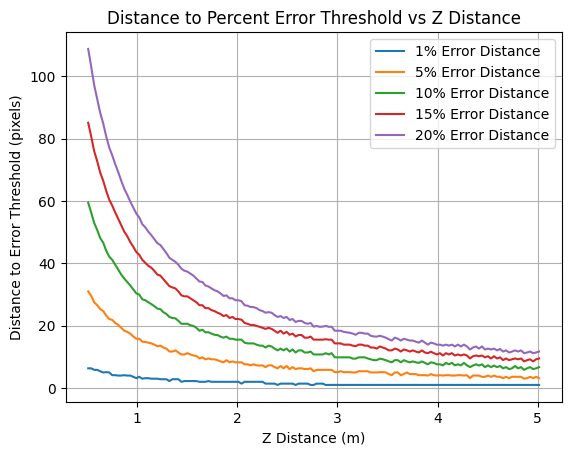

In [9]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 0.5:
        continue

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

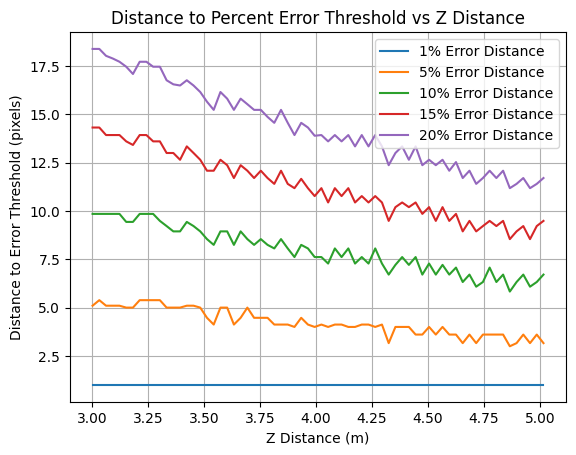

In [10]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 3:
        continue

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

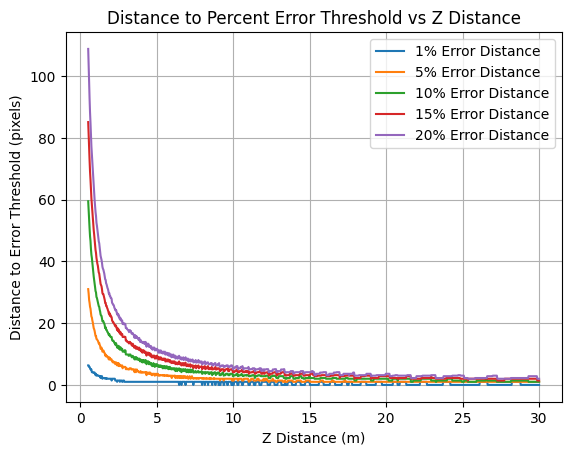

In [11]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 0.5:
        continue
    
    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

In [12]:
p_left = p.copy()
p_left[0, :] -= LASER_DIAMETER_M / 2

p_right = p.copy()
p_right[0, :] += LASER_DIAMETER_M / 2

p_up = p.copy()
p_up[1, :] += LASER_DIAMETER_M / 2

p_down = p.copy()
p_down[1, :] -= LASER_DIAMETER_M / 2

p_left[:, 0], p_right[:, 0], p_up[:, 0], p_down[:, 0]

(array([-0.0428, -0.11  ,  0.    ]),
 array([-0.0372, -0.11  ,  0.    ]),
 array([-0.04  , -0.1072,  0.    ]),
 array([-0.04  , -0.1128,  0.    ]))

In [13]:
s_left = p_left / p_left[2, :]
s_left = camera_intrinsics @ s_left

s_right = p_right / p_right[2, :]
s_right = camera_intrinsics @ s_right

s_up = p_up / p_up[2, :]
s_up = camera_intrinsics @ s_up

s_down = p_down / p_down[2, :]
s_down = camera_intrinsics @ s_down

s_left[:, 0], s_right[:, 0], s_up[:, 0], s_down[:, 0]

/tmp/ipykernel_1493181/292300546.py:1: RuntimeWarning: divide by zero encountered in divide
  s_left = p_left / p_left[2, :]
/tmp/ipykernel_1493181/292300546.py:1: RuntimeWarning: invalid value encountered in divide
  s_left = p_left / p_left[2, :]
/tmp/ipykernel_1493181/292300546.py:2: RuntimeWarning: invalid value encountered in matmul
  s_left = camera_intrinsics @ s_left
/tmp/ipykernel_1493181/292300546.py:4: RuntimeWarning: divide by zero encountered in divide
  s_right = p_right / p_right[2, :]
/tmp/ipykernel_1493181/292300546.py:4: RuntimeWarning: invalid value encountered in divide
  s_right = p_right / p_right[2, :]
/tmp/ipykernel_1493181/292300546.py:5: RuntimeWarning: invalid value encountered in matmul
  s_right = camera_intrinsics @ s_right
/tmp/ipykernel_1493181/292300546.py:7: RuntimeWarning: divide by zero encountered in divide
  s_up = p_up / p_up[2, :]
/tmp/ipykernel_1493181/292300546.py:7: RuntimeWarning: invalid value encountered in divide
  s_up = p_up / p_up[2, :]

(array([nan, nan, nan]),
 array([nan, nan, nan]),
 array([nan, nan, nan]),
 array([nan, nan, nan]))

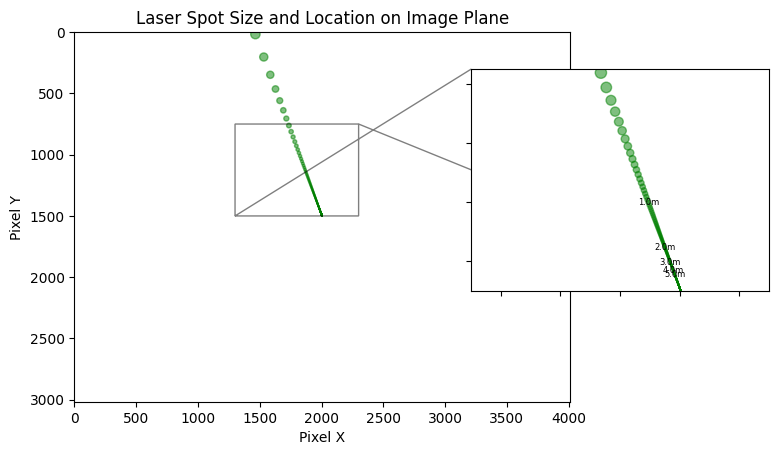

In [14]:
fig, ax = plt.subplots()

prev_z_value_shown = -1
x1, x2 = 1300, 2300
y1, y2 = 750, 1500
axins = ax.inset_axes([0.8, 0.3, 0.6, 0.6], xlim=(x1, x2), ylim=(y2, y1), xticklabels=[], yticklabels=[])

for idx in range(s.shape[1]):
    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    z_value = int(p[2, idx])
    if z_value != prev_z_value_shown and z_value < 6:
        # ax.text(center_x, center_y, f'{p[2, idx]:.1f}m', color='black', fontsize=8, ha='center', va='center')
        axins.text(center_x, center_y, f'{p[2, idx]:.1f}m', color='black', fontsize=6, ha='center', va='center')
        prev_z_value_shown = z_value

    ellipse = Ellipse((center_x, center_y), width, height, edgecolor='g', facecolor='g', alpha=0.5)
    ax.add_patch(ellipse)

    ellipse = Ellipse((center_x, center_y), width, height, edgecolor='g', facecolor='g', alpha=0.5)
    axins.add_patch(ellipse)

# ax.set_aspect('equal', adjustable='datalim') # Adjusts the aspect ratio of the plot
# ax.autoscale() # Adjusts axis limits to fully contain the patch
ax.set_xbound(0, IMAGE_WIDTH)
ax.set_ybound(0, IMAGE_HEIGHT)
ax.set_xlabel('Pixel X')
ax.set_ylabel('Pixel Y')
ax.set_title('Laser Spot Size and Location on Image Plane')

# axins.invert_yaxis()
ax.invert_yaxis()

ax.indicate_inset_zoom(axins, edgecolor="black")

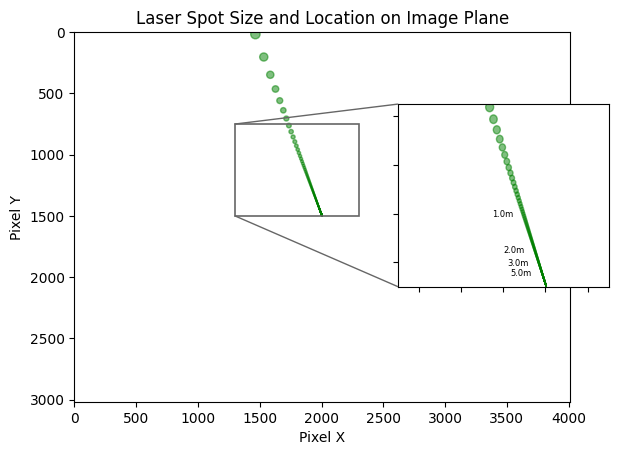

In [15]:
# reference

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch, Ellipse

fig, ax = plt.subplots()

# --- your zoom ROI in *data* (pixel) coords
x1, x2 = 1300, 2300
y1, y2 = 750, 1500

# IMPORTANT: make parent axis "image style"
ax.set_xlim(0, IMAGE_WIDTH)
ax.set_ylim(IMAGE_HEIGHT, 0)  # top-down pixels

# ---- create inset OUTSIDE using figure coordinates
# [left, bottom, width, height] in figure fraction
axins = fig.add_axes([0.63, 0.35, 0.33, 0.38])   # tweak these to taste (outside)
axins.set_xlim(x1, x2)
axins.set_ylim(y2, y1)                           # image style in inset too
axins.set_xticklabels([])
axins.set_yticklabels([])

# --- your plotting (ellipses + labels) on BOTH axes
prev_z_value_shown = -1
for idx in range(s.shape[1]):
    center_x = s[0, idx]
    center_y = s[1, idx]
    width  = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx]    - s_down[1, idx]

    z_value = int(p[2, idx])
    if z_value != prev_z_value_shown and z_value < 6 and z_value != 4:
        axins.text(center_x - 100, center_y, f'{p[2, idx]:.1f}m',
                   color='black', fontsize=6, ha='center', va='center')
        prev_z_value_shown = z_value

    e = Ellipse((center_x, center_y), width, height,
                edgecolor='g', facecolor='g', alpha=0.5)
    ax.add_patch(e)
    axins.add_patch(Ellipse((center_x, center_y), width, height,
                            edgecolor='g', facecolor='g', alpha=0.5))

# --- draw the zoom rectangle on the main axes
roi = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec="0.4", lw=1.2)
ax.add_patch(roi)

# --- connect rectangle corners to inset corners (outside) with ConnectionPatch
# Use two corners (choose whichever looks best)
con1 = ConnectionPatch(
    xyA=(0, 1), coordsA=axins.transAxes,   # inset top-left
    xyB=(x1, y1), coordsB=ax.transData,    # roi top-left in data coords
    color="0.4", lw=1.0, clip_on=False
)
con2 = ConnectionPatch(
    xyA=(0, 0), coordsA=axins.transAxes,   # inset bottom-left
    xyB=(x1, y2), coordsB=ax.transData,    # roi bottom-left
    color="0.4", lw=1.0, clip_on=False
)
fig.add_artist(con1)
fig.add_artist(con2)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")
ax.set_title("Laser Spot Size and Location on Image Plane")
plt.show()

# Describe the target range.  ie 0.5m to 5m

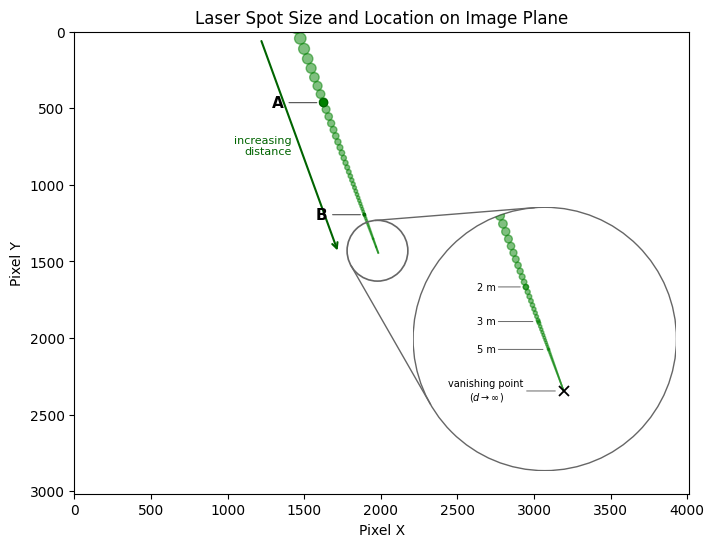

In [18]:
# change me

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch, Ellipse, Circle
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ── Log-spaced path samples + forced 2/3/5 m anchors ─────────────────────
min_z, max_z, n_log = 0.10, 500.0, 180

# The two sample distances panel (b) of the principle figure marks on the laser
# ray. Panel (c) has to show where those same two points land on the image
# plane, so they are forced into the sample set and labelled below. Change them
# here and the figure follows; they must match the tikz panel.
A_DISTANCE_M = 0.30
B_DISTANCE_M = 1.00

forced_z = np.array([A_DISTANCE_M, B_DISTANCE_M, 2.0, 3.0, 5.0])
all_z = np.sort(np.unique(np.concatenate([np.geomspace(min_z, max_z, n_log),
                                          forced_z])))

all_p       = laser_position[:, None] + all_z[None, :] * laser_direction[:, None]
all_p_left  = all_p.copy(); all_p_left[0, :]  -= LASER_DIAMETER_M / 2
all_p_right = all_p.copy(); all_p_right[0, :] += LASER_DIAMETER_M / 2
all_p_up    = all_p.copy(); all_p_up[1, :]    += LASER_DIAMETER_M / 2
all_p_down  = all_p.copy(); all_p_down[1, :]  -= LASER_DIAMETER_M / 2

all_s       = camera_intrinsics @ (all_p       / all_p[2, :])
all_s_left  = camera_intrinsics @ (all_p_left  / all_p_left[2, :])
all_s_right = camera_intrinsics @ (all_p_right / all_p_right[2, :])
all_s_up    = camera_intrinsics @ (all_p_up    / all_p_up[2, :])
all_s_down  = camera_intrinsics @ (all_p_down  / all_p_down[2, :])

dots  = []
trail = []
for j in range(all_z.shape[0]):
    cx, cy = all_s[0, j], all_s[1, j]
    z = all_z[j]
    w = all_s_right[0, j] - all_s_left[0, j]
    h = all_s_up[1, j]    - all_s_down[1, j]
    if not (np.isfinite(cx) and np.isfinite(cy) and np.isfinite(w) and np.isfinite(h)):
        continue
    if w <= 0 or h <= 0:
        continue
    entry = (cx, cy, z, w, h)
    if z <= 5.0:
        dots.append(entry)
    else:
        trail.append(entry)

if not dots:
    raise RuntimeError("No valid dot centers found.")

visible = [d for d in dots
           if 0 <= d[0] <= IMAGE_WIDTH and 0 <= d[1] <= IMAGE_HEIGHT]
far_dots = [d for d in visible if 4.0 <= d[2] <= 5.0]

# ── Label anchor dots (2/3/5 m) ──────────────────────────────────────────
label_targets = (2, 3, 5)
label_anchors = {}
for target in label_targets:
    for cx, cy, z, w, h in dots:
        if abs(z - target) < 1e-9:
            label_anchors[target] = (cx, cy)
            break

# ── Square ROI — one radius so the circular inset is a true circle ───────
vp_x, vp_y = IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2
anchor_xs = [d[0] for d in far_dots] + [vp_x] + [a[0] for a in label_anchors.values()]
anchor_ys = [d[1] for d in far_dots] + [vp_y] + [a[1] for a in label_anchors.values()]

center_x = (min(anchor_xs) + max(anchor_xs)) / 2
center_y = (min(anchor_ys) + max(anchor_ys)) / 2
half_span = max(max(anchor_xs) - min(anchor_xs),
                max(anchor_ys) - min(anchor_ys)) / 2
radius = half_span + 120   # extra padding so labels fit on the left

x1, x2 = center_x - radius, center_x + radius
y1, y2 = center_y - radius, center_y + radius

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, IMAGE_WIDTH)
ax.set_ylim(IMAGE_HEIGHT, 0)
ax.set_aspect('equal')
ax.set_xlabel('Pixel X')
ax.set_ylabel('Pixel Y')
ax.set_title('Laser Spot Size and Location on Image Plane')

# Inset placed in the bottom-right so its circle clears the ROI circle.
axins = ax.inset_axes([0.55, 0.05, 0.43, 0.57])
axins.set_xlim(x1, x2)
axins.set_ylim(y2, y1)
axins.set_aspect('equal')
axins.set_xticks([])
axins.set_yticks([])
axins.patch.set_visible(False)
for spine in axins.spines.values():
    spine.set_visible(False)

# Circular clip + visual frame (in axes-fraction coords, so it's always a
# perfect circle as long as the axes box ends up square under set_aspect).
clip_circle = Circle((0.5, 0.5), 0.5, transform=axins.transAxes,
                     facecolor='white', edgecolor='0.4',
                     linewidth=1.0, zorder=-10)
axins.add_patch(clip_circle)

def _add_clipped_patch(owner, patch):
    owner.add_patch(patch)
    patch.set_clip_path(clip_circle)
    return patch

# ── Primary ellipses (0–5 m) ────────────────────────────────────────────
for cx, cy, z, w, h in dots:
    ax.add_patch(Ellipse((cx, cy), w, h,
                         edgecolor='g', facecolor='g', alpha=0.5))
    _add_clipped_patch(axins, Ellipse((cx, cy), w, h,
                                      edgecolor='g', facecolor='g', alpha=0.5))

# ── Trail ellipses (>5 m) — inset only ──────────────────────────────────
for cx, cy, z, w, h in trail:
    if not (x1 <= cx <= x2 and y1 <= cy <= y2):
        continue
    _add_clipped_patch(axins, Ellipse((cx, cy), w, h,
                                      edgecolor='g', facecolor='g', alpha=0.5))

# ── Distance labels with leader lines — aligned on a single left column ──
# Pushed inward so longer labels (e.g. "vanishing point") clear the circle.
label_x = x1 + 110
labels_in_inset = {t: a for t, a in label_anchors.items()
                   if x1 <= a[0] <= x2 and y1 <= a[1] <= y2}
for z_int in sorted(labels_in_inset):
    cx, cy = labels_in_inset[z_int]
    ly = max(y1 + 25, min(y2 - 25, cy))
    annot = axins.annotate(
        f'{z_int} m',
        xy=(cx, cy), xytext=(label_x, ly),
        fontsize=7, color='black', ha='center', va='center',
        arrowprops=dict(arrowstyle='-', color='0.3',
                        lw=0.6, shrinkA=0, shrinkB=4))
    annot.set_clip_path(clip_circle)
    if annot.arrow_patch is not None:
        annot.arrow_patch.set_clip_path(clip_circle)

# ── Vanishing point — marker + annotation inside the inset ───────────────
vp_marker, = axins.plot(vp_x, vp_y, marker='x', color='black',
                        markersize=7, markeredgewidth=1.3, zorder=5)
vp_marker.set_clip_path(clip_circle)

vp_label_y = max(y1 + 25, min(y2 - 25, vp_y))
vp_annot = axins.annotate(
    'vanishing point\n$(d \\rightarrow \\infty)$',
    xy=(vp_x, vp_y), xytext=(label_x, vp_label_y),
    fontsize=7, color='black', ha='center', va='center',
    arrowprops=dict(arrowstyle='-', color='0.3',
                    lw=0.6, shrinkA=0, shrinkB=6))
vp_annot.set_clip_path(clip_circle)
if vp_annot.arrow_patch is not None:
    vp_annot.arrow_patch.set_clip_path(clip_circle)

# ── A / B sample points — the two distances panel (b) marks ─────────────
ab_anchors = {}
for name, target in (('A', A_DISTANCE_M), ('B', B_DISTANCE_M)):
    for cx, cy, z, w, h in dots:
        if abs(z - target) < 1e-9:
            ab_anchors[name] = (cx, cy, w, h)
            break
    else:
        raise RuntimeError(f"{name} at {target} m is not in the sampled path")

for name, (cx, cy, w, h) in ab_anchors.items():
    # Redraw the anchor opaque so it reads as a marked point, not just another
    # ellipse in the trail.
    ax.add_patch(Ellipse((cx, cy), w, h, edgecolor='darkgreen',
                         facecolor='g', alpha=1.0, lw=0.8, zorder=6))
    ax.annotate(
        name,
        xy=(cx - w / 2, cy), xytext=(-13, 0), textcoords='offset points',
        fontsize=11, fontweight='bold', color='black',
        ha='right', va='center', zorder=7,
        arrowprops=dict(arrowstyle='-', color='0.3', lw=0.8,
                        shrinkA=2, shrinkB=2))

# ── Zoom indicator on main axes — circle inscribed in the ROI square ────
ax.add_patch(Circle((center_x, center_y), radius,
                    fill=False, ec='0.4', lw=1.2))

# ── Connection lines — true external tangents of both circles ────────────
# Force layout so transforms reflect aspect='equal' adjustments.
fig.canvas.draw()

roi_c = np.array(ax.transData.transform((center_x, center_y)))
roi_r_disp = abs(ax.transData.transform((center_x + radius, center_y))[0] - roi_c[0])
ins_c = np.array(axins.transAxes.transform((0.5, 0.5)))
ins_r_disp = abs(axins.transAxes.transform((1.0, 0.5))[0] - ins_c[0])

delta = ins_c - roi_c
d_disp = np.linalg.norm(delta)
u = delta / d_disp
v = np.array([-u[1], u[0]])
a_coef = (roi_r_disp - ins_r_disp) / d_disp
b_coef = np.sqrt(max(0.0, 1.0 - a_coef**2))
n_upper = a_coef * u + b_coef * v
n_lower = a_coef * u - b_coef * v

for n in (n_upper, n_lower):
    roi_tp_disp = roi_c + roi_r_disp * n
    ins_tp_disp = ins_c + ins_r_disp * n
    roi_tp_data = ax.transData.inverted().transform(roi_tp_disp)
    ins_tp_ax   = axins.transAxes.inverted().transform(ins_tp_disp)
    fig.add_artist(ConnectionPatch(
        xyA=tuple(ins_tp_ax), coordsA=axins.transAxes,
        xyB=tuple(roi_tp_data), coordsB=ax.transData,
        color='0.4', lw=1.0, clip_on=False,
    ))

# ── "increasing distance" arrow — diagonal along the path, offset left ───
by_z = sorted(visible, key=lambda d: d[2])
near_cx, near_cy = by_z[0][0],  by_z[0][1]
far_cx,  far_cy  = by_z[-1][0], by_z[-1][1]

offset_x = 260
tail_x = max(120, near_cx - offset_x)
tail_y = near_cy
head_x = max(120, far_cx  - offset_x)
head_y = far_cy

ax.annotate('', xy=(head_x, head_y), xytext=(tail_x, tail_y),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5))
ax.text((tail_x + head_x) / 2 - 50, (tail_y + head_y) / 2,
        'increasing\ndistance',
        fontsize=8, color='darkgreen', ha='right', va='center')

fig.savefig('figures/laser_spot_path.pdf', dpi=300, bbox_inches='tight')
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/chris/Repos/school/e4e/fishsense/imwut_2026_fishsense_lite/fishsense_imwut/camera.py:39: RuntimeWarning: divide by zero encountered in divide
  point_constants_noisy = (
/home/chris/Repos/school/e4e/fishsense/imwut_2026_fishsense_lite/fishsense_imwut/camera.py:43: RuntimeWarning: invalid value encountered in multiply
  world_points = np.tile(point_constants_noisy, (3, 1)) * final_laser_axis


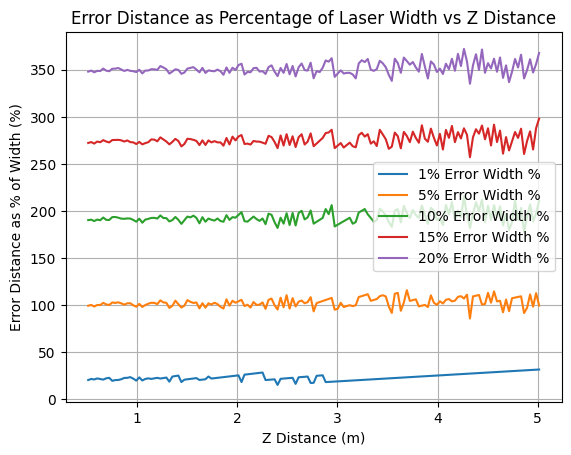

In [17]:
z_values = []
widths = []
heights = []

one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for idx in tqdm(range(s.shape[1])):
    if p[2, idx] < 0.5:
        continue

    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, idx]) / p[2, idx] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, idx], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, idx])
    widths.append(width)
    heights.append(height)

    if p[2, idx] > 5:
        break
    
one_percent_error_distance = np.array(one_percent_error_distance)
five_percent_error_distance = np.array(five_percent_error_distance)
ten_percent_error_distance = np.array(ten_percent_error_distance)
fifteen_percent_error_distance = np.array(fifteen_percent_error_distance)
twenty_percent_error_distance = np.array(twenty_percent_error_distance)

z_values = np.array(z_values)
widths = np.array(widths)
heights = np.array(heights)

one_percent_width_percent = one_percent_error_distance / widths * 100
one_percent_height_percent = one_percent_error_distance / heights * 100
five_percent_width_percent = five_percent_error_distance / widths * 100
five_percent_height_percent = five_percent_error_distance / heights * 100
ten_percent_width_percent = ten_percent_error_distance / widths * 100
ten_percent_height_percent = ten_percent_error_distance / heights * 100
fifteen_percent_width_percent = fifteen_percent_error_distance / widths * 100
fifteen_percent_height_percent = fifteen_percent_error_distance / heights * 100
twenty_percent_width_percent = twenty_percent_error_distance / widths * 100
twenty_percent_height_percent = twenty_percent_error_distance / heights * 100

plt.plot(z_values, one_percent_width_percent, label='1% Error Width %')
plt.plot(z_values, five_percent_width_percent, label='5% Error Width %')
plt.plot(z_values, ten_percent_width_percent, label='10% Error Width %')
plt.plot(z_values, fifteen_percent_width_percent, label='15% Error Width %')
plt.plot(z_values, twenty_percent_width_percent, label='20% Error Width %')
plt.xlabel('Z Distance (m)')
plt.ylabel('Error Distance as % of Width (%)')
plt.title('Error Distance as Percentage of Laser Width vs Z Distance')
plt.legend()
plt.grid()